# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Inspect the shapes of the datasets
print(f"Training images shape:{X_train.shape}")
print(f"Test images shape:{X_test.shape}")


Training images shape:(60000, 28, 28)
Test images shape:(10000, 28, 28)


In [5]:
# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)

print(f"One-hot encoded label:{y_train_oh[0]}")
print(f"Shape of y_train_oh:{y_train_oh.shape}")


One-hot encoded label:[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Shape of y_train_oh:(60000, 10)


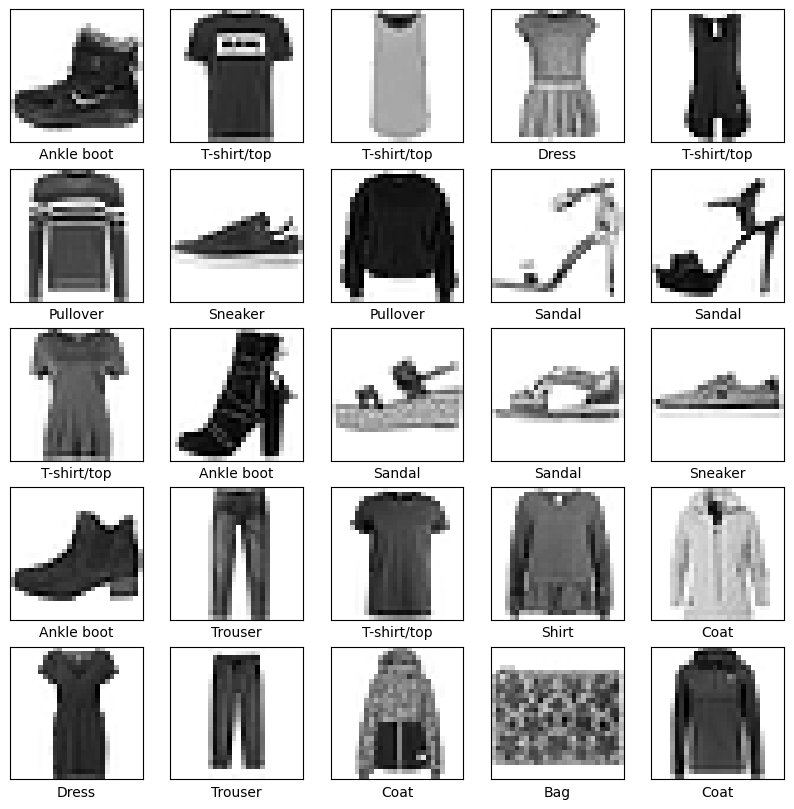

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    plt.imshow(X_train[i].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The data look as expected. The quality is 28x28 pixels. One of the issue is the similarity of "Top", by looking at the images, it difficult for us to tell whether this "Top" is e.g. "Pullover" or "Long-sleeves Shirt".


# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

# Input layer
model.add(Flatten(input_shape=(28, 28)))

# Add layers
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax'))



In [13]:
# Compile the model with an appropriate loss function and optimizer
# Using `model.compile()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model on the training set with 10 epochs 
# Using model.fit()
history = model.fit(
    X_train, 
    y_train, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8231 - loss: 0.4853 - val_accuracy: 0.8543 - val_loss: 0.4023
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8660 - loss: 0.3629 - val_accuracy: 0.8648 - val_loss: 0.3599
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8778 - loss: 0.3275 - val_accuracy: 0.8808 - val_loss: 0.3362
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8873 - loss: 0.3023 - val_accuracy: 0.8777 - val_loss: 0.3408
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8940 - loss: 0.2826 - val_accuracy: 0.8783 - val_loss: 0.3400
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8987 - loss: 0.2683 - val_accuracy: 0.8668 - val_loss: 0.3620
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9040 - loss: 0.2561 - val_accuracy: 0.8873 - val_loss: 0.3256
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9085 - loss: 0

In [17]:
# Evaluate it on the test set
# Using model.evaluate()
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

print(f'Test accuracy: {test_acc*100:.2f}%')
print(f'Test loss: {test_loss:.4f}')


313/313 - 1s - 3ms/step - accuracy: 0.8770 - loss: 0.3720
Test accuracy: 87.70%
Test loss: 0.3720


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The performance of the baseline model lands 87.7% accuracy. This is what exactly we expect. The performance is at this level, e.g. not too high, because one of the issue is the similarity of "Top", by looking at the images, it difficult for us to tell whether this "Top" is e.g. "Pullover" or "Long-sleeves Shirt". 


# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from tensorflow.keras import models, layers

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model_cnn = models.Sequential()

# Convolutional layer to learn spatial hierarchies in images
model_cnn.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Pooling Layer to reduces the spatial dimensions
model_cnn.add(layers.MaxPooling2D((2, 2)))

# Flatten 
model_cnn.add(layers.Flatten())

# Fully connected layer to make predictions
model_cnn.add(layers.Dense(128, activation='relu'))

# Output Layer with 10 neurons using Softmax
model_cnn.add(layers.Dense(10, activation='softmax'))

# Compile the model with optimizer, loss function and metrics
# Compile the model
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model_cnn.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train the model on the training set with 10 epochs
history_cnn = model_cnn.fit(
    X_train, 
    y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8467 - loss: 0.4373 - val_accuracy: 0.8762 - val_loss: 0.3385
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8949 - loss: 0.2935 - val_accuracy: 0.8965 - val_loss: 0.2917
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9100 - loss: 0.2481 - val_accuracy: 0.9027 - val_loss: 0.2768
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9214 - loss: 0.2158 - val_accuracy: 0.9092 - val_loss: 0.2566
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9318 - loss: 0.1888 - val_accuracy: 0.9140 - val_loss: 0.2490
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9384 - loss: 0.1668 - val_accuracy: 0.9082 - val_loss: 0.2562
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9459 - loss: 0.1461 - val_accuracy: 0.9042 - val_loss: 0.2769
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9537 - loss: 0.1287 - 

In [24]:
# Evaluate the model on the test set
test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=2)

print(f'Final Test Accuracy: {test_acc*100:.2f}%')


313/313 - 1s - 4ms/step - accuracy: 0.9137 - loss: 0.2731
Final Test Accuracy: 91.37%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Yes, the CNN model (test accurancy: 91.37%) perform better than the baseline model (test accurancy: 87.7%) by 3.67% test accurancy.  

One of the factors that contributed to this improvement is that CNN use convolutional layers to detect local patterns and then combine them into higher-level features. A baseline model "shuffles" this spatial context when it flattens the image into a 1D vector.


# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
# A. Test Hyperparameters
from tensorflow.keras import models, layers
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hyperparameters with 32, 64, 128 filters
filter_options = [32, 64, 128]
reg_options = [False, True]  
all_results = []

for use_dropout in reg_options:
    for num_filters in filter_options:
        reg_label = "With Dropout" if use_dropout else "No Dropout"
        print(f"Testing: {num_filters} Filters | {reg_label}...")
        
        model = models.Sequential()
        model.add(layers.Conv2D(num_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu'))
        
        # Test presence or absence of regularization
        if use_dropout:
            model.add(layers.Dropout(0.5))
            
        model.add(layers.Dense(10, activation='softmax'))
        
        # Compile and Train
        model.compile(optimizer='adam', 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])
        
        # Fit the model
        model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0, validation_split=0.1)
        


Testing: 32 Filters | No Dropout...


c:\Users\User\deep_learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testing: 64 Filters | No Dropout...
Testing: 128 Filters | No Dropout...
Testing: 32 Filters | With Dropout...
Testing: 64 Filters | With Dropout...
Testing: 128 Filters | With Dropout...

--- Summary of Test Accuracies ---
Regularization  No Dropout  With Dropout
Filters                                 
32                  0.9111        0.9024
64                  0.9102        0.9026
128                 0.9073        0.9052


In [ ]:
# Evaluate on test test
# Record Results include test accurancy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
all_results.append({
            'Filters': num_filters,
            'Regularization': reg_label,
            'Test_Accuracy': test_acc
        })
print(f'Final Test Accuracy: {test_acc*100:.2f}%')


Final Test Accuracy: 90.52%


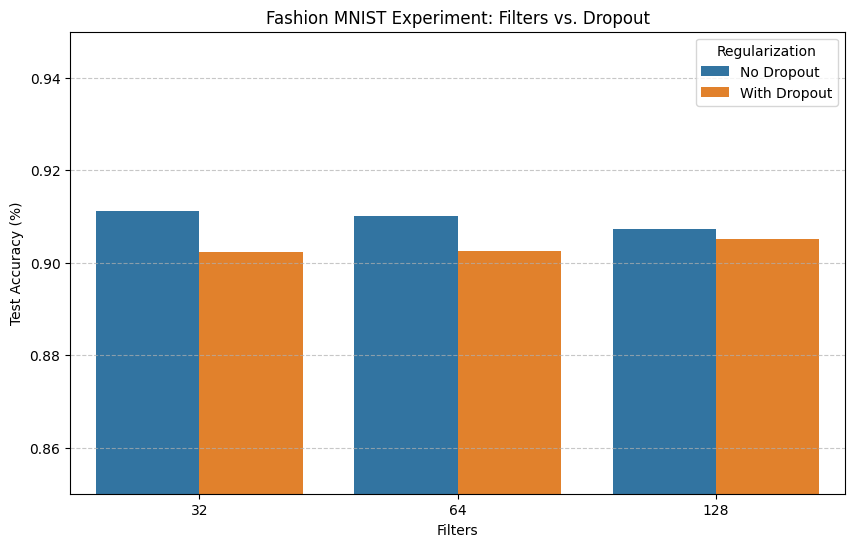

In [ ]:
# Visualize the results by plots
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Filters', y='Test_Accuracy', hue='Regularization')
plt.title('Fashion MNIST Experiment: Filters vs. Dropout')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0.85, 0.95) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Filters and Dropout are both critical changes to make improve the model's performance. 

Filters allowed the model to detect for very specific features.Dropout prevented the model from relying on a single pixel to identify a class. It forced the network to learn redundant, which are much more reliable on unseen test data.

Hyperparameter: 128 Filters (High capacity for feature extraction).
Regularization: With Dropout (0.5) (Crucial for preventing memorization).

The combination of 32 filters with no dropout techniques yielded the best performance (91.11%).

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [33]:
from tensorflow.keras import models, layers

# Compile the final model with 
# Best performing setup: 32 filters, No Dropout
final_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Flattening for the dense classifier
    layers.Flatten(),
    
    # Fully connected layer (128 neurons was our experimental standard)
    layers.Dense(128, activation='relu'),
    
    # Final output for 10 fashion classes
    layers.Dense(10, activation='softmax')
])

# Compile with Adam optimizer for stable convergence
final_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

final_model.summary()


c:\Users\User\deep_learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train the final model on the training set 
history_final = final_model.fit(
    X_train, 
    y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8493 - loss: 0.4295 - val_accuracy: 0.8825 - val_loss: 0.3337
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8967 - loss: 0.2888 - val_accuracy: 0.9013 - val_loss: 0.2711
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9112 - loss: 0.2461 - val_accuracy: 0.9010 - val_loss: 0.2723
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9232 - loss: 0.2110 - val_accuracy: 0.9065 - val_loss: 0.2612
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9334 - loss: 0.1843 - val_accuracy: 0.9142 - val_loss: 0.2473
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9411 - loss: 0.1634 - val_accuracy: 0.9162 - val_loss: 0.2412
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9468 - loss: 0.1448 - val_accuracy: 0.9123 - val_loss: 0.2569
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9544 - loss: 0.1256 - 

In [35]:
# Evaluate it on the test set
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=2)

# Report the final model's accuracy and loss.
print(f"Final Model Performance")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")


313/313 - 1s - 4ms/step - accuracy: 0.9115 - loss: 0.2770
Final Model Performance
Test Accuracy: 91.15%
Test Loss:     0.2770


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

Compare to the baseline anad the CNN model, the final model's performance seems to be better than baseline model but slighlty underperform than CNN model. 32 filters and no dropout contributed to the final model's performance. Learning rate would be one of the experiments to test for further improve the model performance.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.